In [22]:
import random as rd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

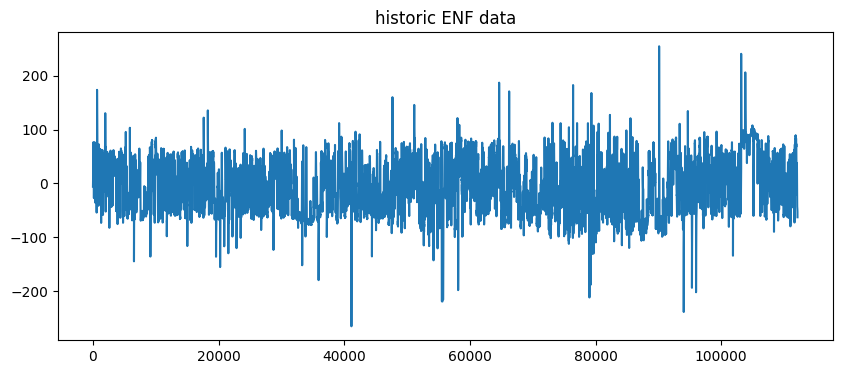

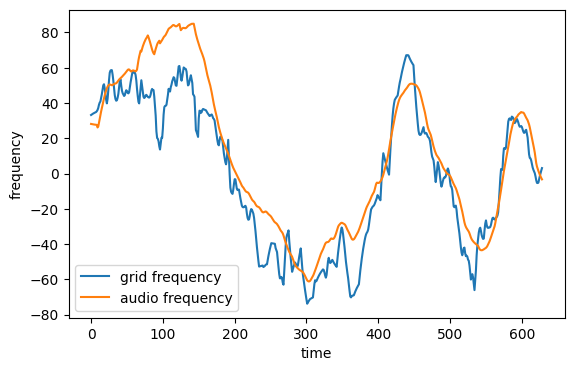

In [23]:
grid_freq = pd.read_csv('./precomp-data/h1-ref-day/day_001_ref_precomp.csv', index_col=0)
grid_freq -= 250

plt.figure(figsize=(10, 4))
plt.plot(grid_freq)
plt.title('historic ENF data')
plt.show()

audio_freq = pd.read_csv('./precomp-data/h1/001.csv', index_col=0) 
audio_freq -= 250

grid_ref_freq = pd.read_csv('./precomp-data/h1-ref/001.csv', index_col=0) 
grid_ref_freq -= 250

plt.figure(figsize=(6.4, 4))
plt.plot(audio_freq)
plt.xlabel('time')
plt.ylabel('frequency')
plt.plot(grid_ref_freq)
plt.legend(['grid frequency', 'audio frequency'])
plt.show()

In [24]:
WIN_LEN = len(audio_freq)

In [25]:
from dtaidistance import dtw
from scipy.spatial.distance import euclidean


def get_features(timeseries, version):
    s1 = timeseries.values.reshape(-1)
    s2 = audio_freq.values.reshape(-1)
    if version == 'euclidean':
        dist = euclidean(s1, s2)
    else: 
        dist = dtw.distance_fast(s1, s2, use_c=True)
    return pd.DataFrame([{'dist': dist}])

def create_features(timeseries, version):
    N = len(timeseries)
    D = pd.DataFrame()
    for i in range(N-WIN_LEN):
        D = pd.concat([D, get_features(timeseries[i:i+WIN_LEN], version)], ignore_index=True)
    return D

In [26]:
D_euclidean = create_features(grid_freq, 'euclidean')
D_dtw = create_features(grid_freq, 'dtw')

timestamps: Index([92676], dtype='int64')


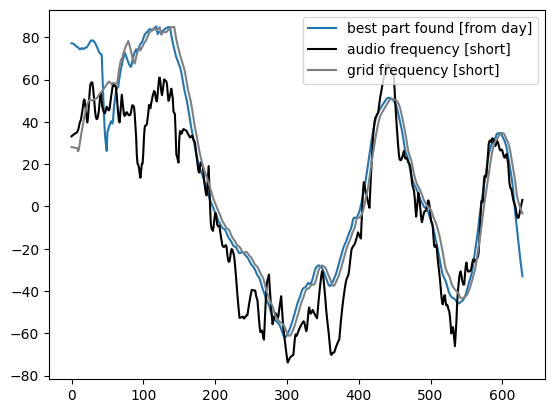

timestamps: Index([50111], dtype='int64')


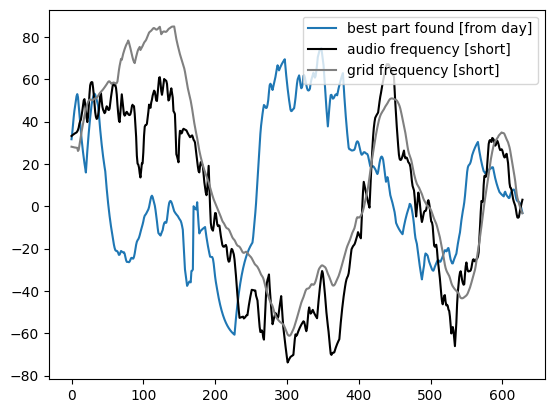

In [39]:


for D in [D_euclidean, D_dtw]:
    D_sorted = D.sort_values(['dist'])
    print(f"timestamps: {D_sorted.index[:1]}")
    for idx in D_sorted.index[:1]:
        plt.plot(grid_freq[idx:idx+WIN_LEN].values)
    plt.plot(audio_freq, c='black')
    plt.plot(grid_ref_freq, c='gray')
    plt.legend(['best part found [from day]', 'audio frequency [short]', 'grid frequency [short]'])
    plt.show()

Conclusion:
- Euclidean distance was able to find appropriate timestamp
- Dtw did not

DTW was integral part of this project, so we tried following approaches:
- calculate features for each time series window 
- fit KNN on those windows
- choose best neighbours
- for each of best neigbours choose the best one using dtw

Unfortunately this did not work. The problem was in:
- noise frequency from audio (impact of noise analised further at the end of location.ipynb)
- shortness of audio (which implied it wasn't as unique)